Import Semua Library


In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib

In [91]:
df = pd.read_csv("train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [92]:
print("Informasi data")
df.info()

Informasi data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64 

In [93]:
df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


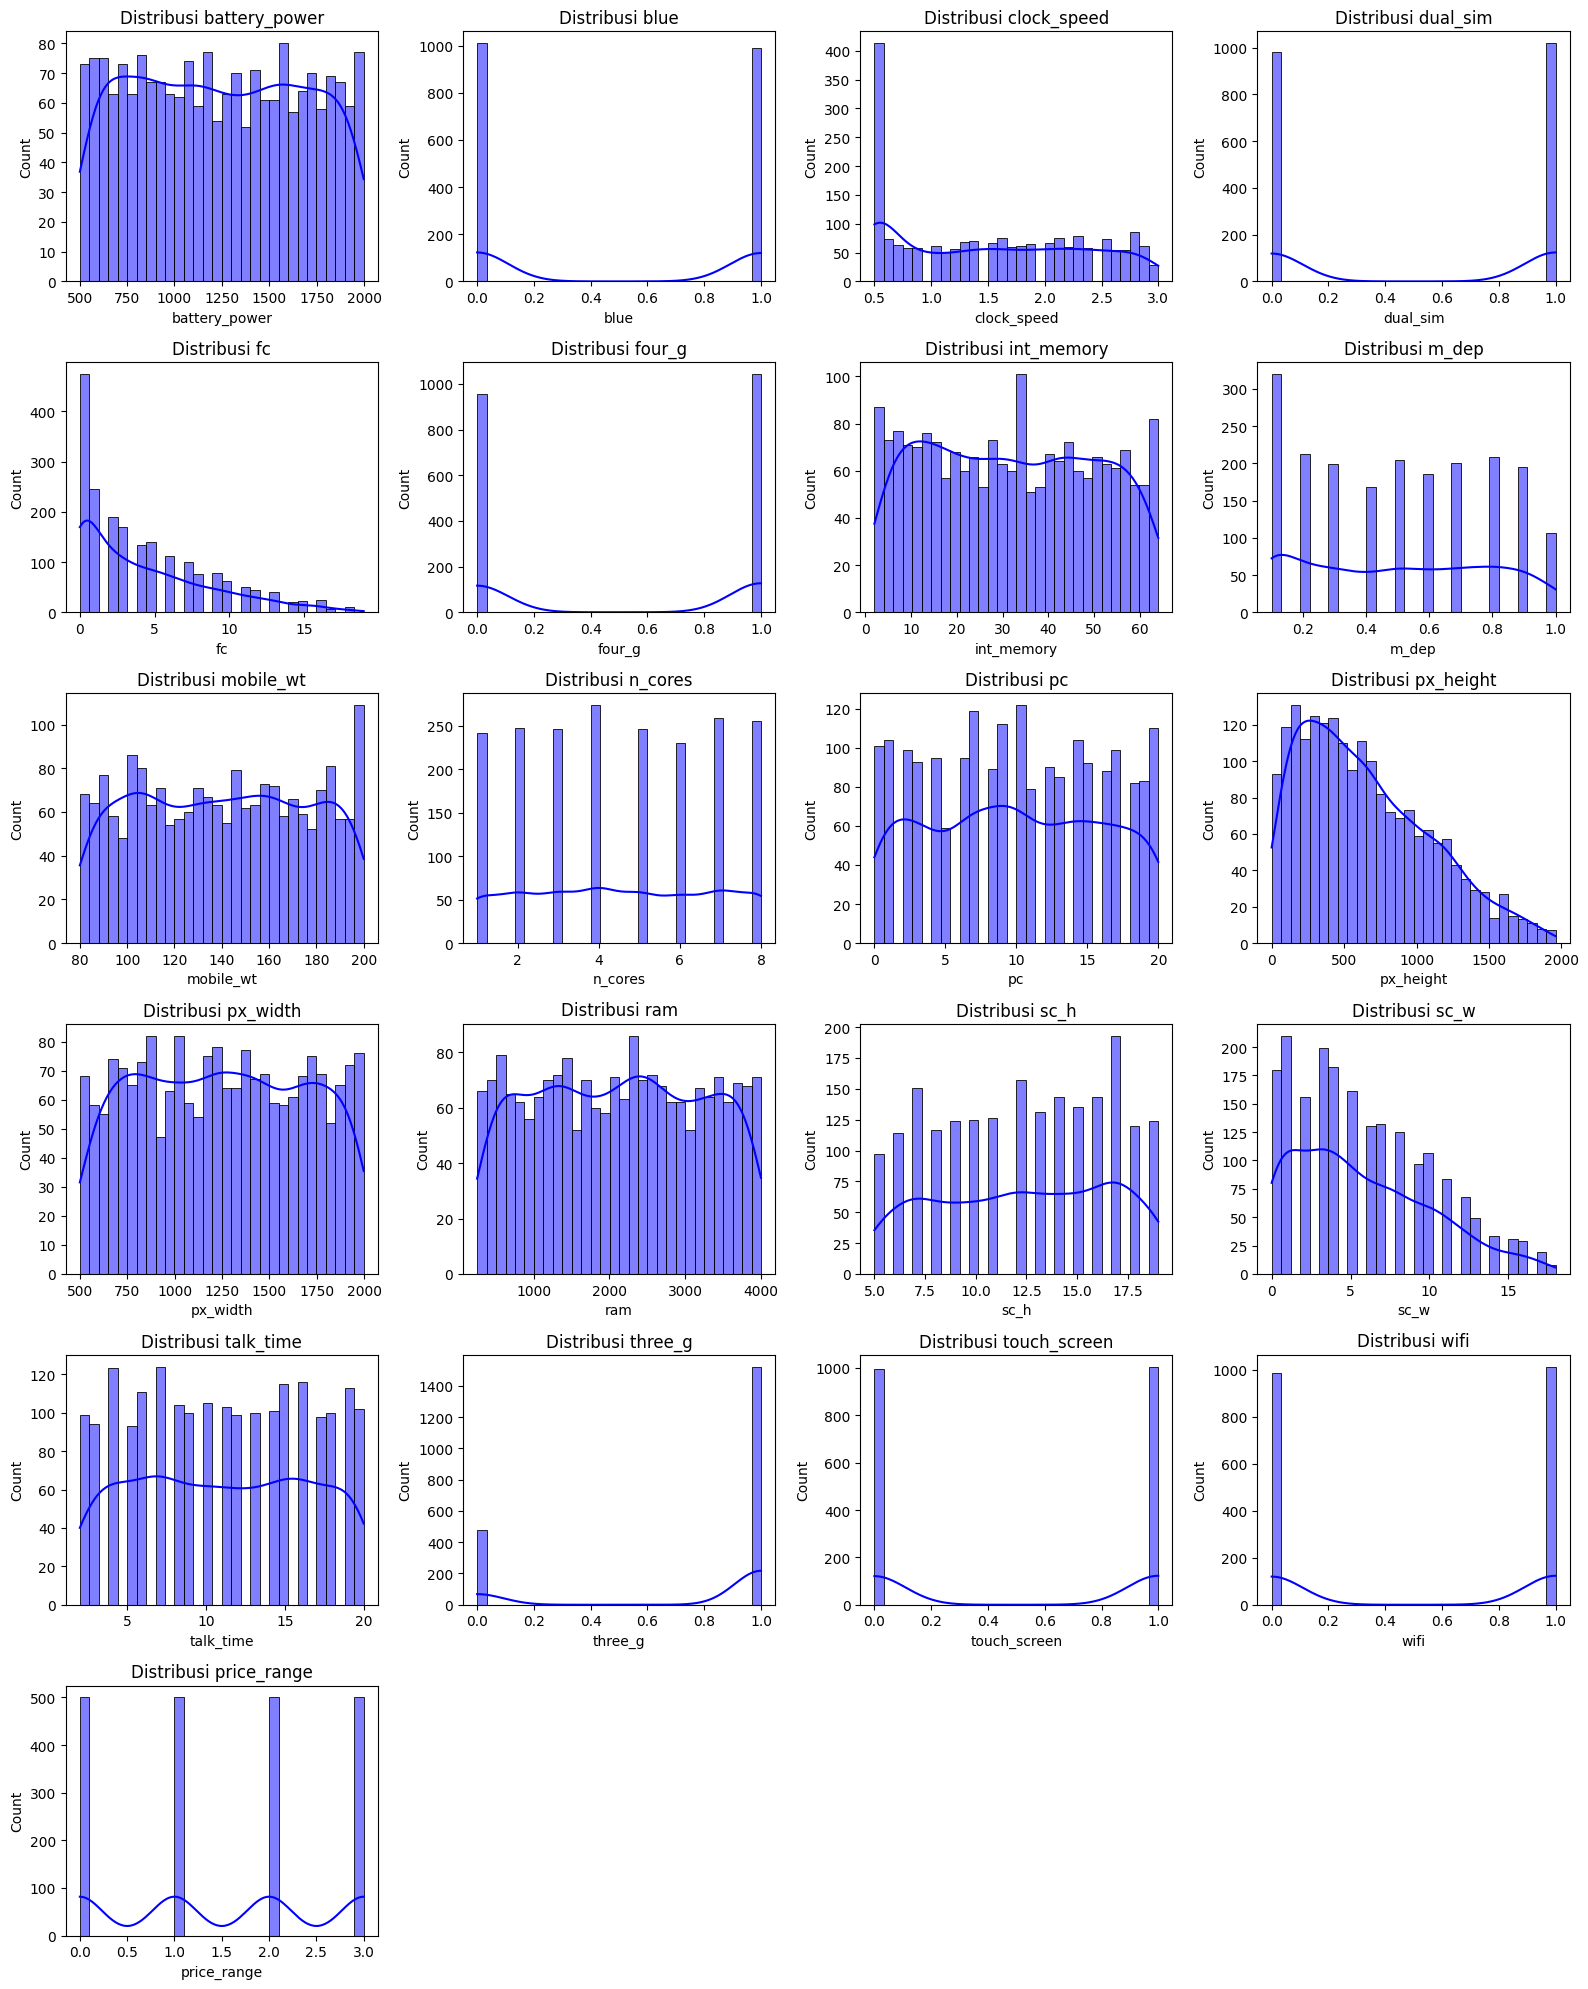

In [94]:
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(16, 20))

num_cols_to_plot = len(num_features.columns)
rows = (num_cols_to_plot + 3) // 4
cols = 4

for i, column in enumerate(num_features.columns, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

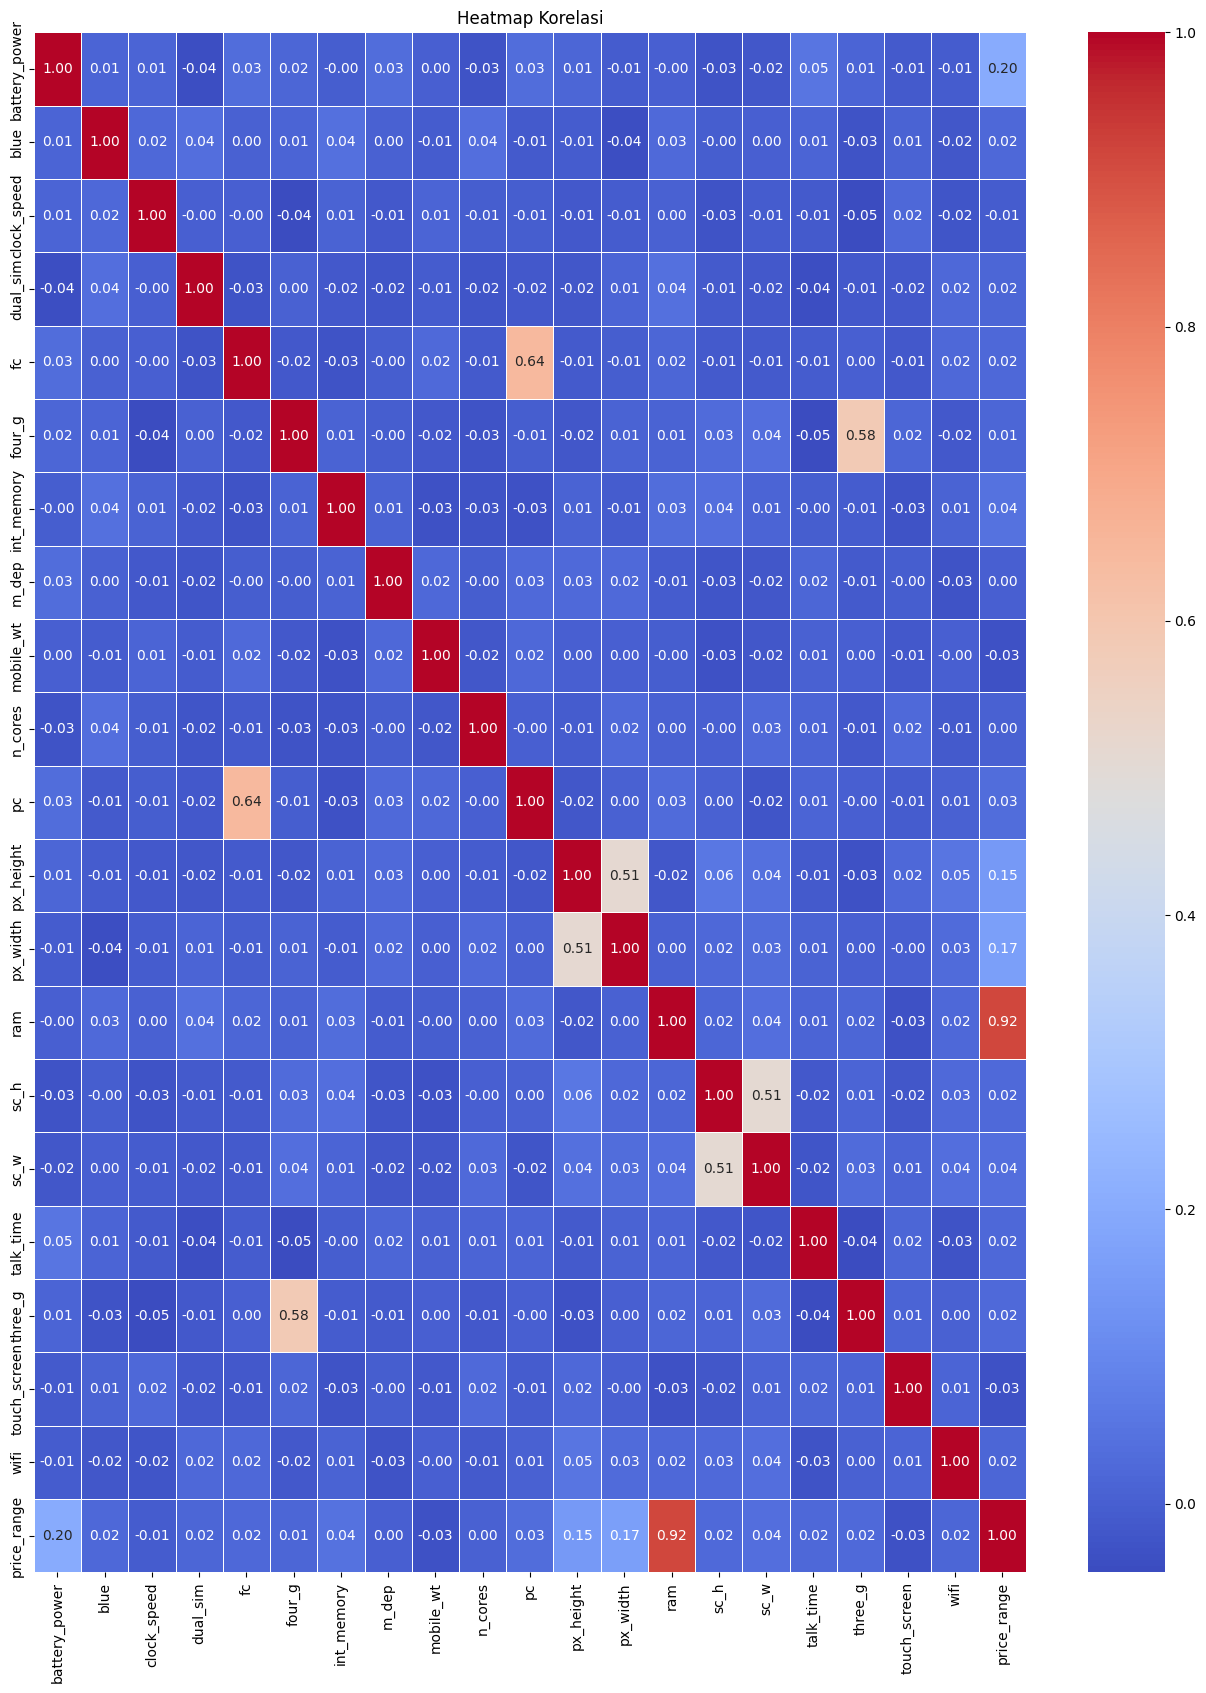

In [95]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(16, 20))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

In [96]:
sns.pairplot(num_features)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_28500/3888812259.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='price_range', data=df, palette='viridis')


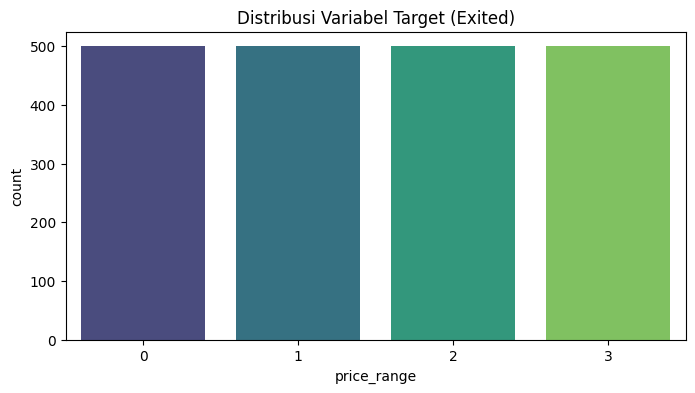

In [97]:
# Visualisasi distribusi variabel target
plt.figure(figsize=(8, 4))
sns.countplot(x='price_range', data=df, palette='viridis')
plt.title('Distribusi Variabel Target (Exited)')
plt.show()

In [98]:
scaler = MinMaxScaler()

X = df.drop(columns=['price_range'])
y = df['price_range']

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi semua kolom numerik
numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")


Training set shape: X_train=(1600, 20), y_train=(1600,)
Test set shape: X_test=(400, 20), y_test=(400,)


In [99]:
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

print("Model training selesai.")

Model training selesai.


In [100]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    return results

results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}

summary_df = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

rows = []
for model_name, metrics in results.items():
    rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })

summary_df = pd.DataFrame(rows)

summary_df

,Model,Accuracy,Precision,Recall,F1-Score
0,K-Nearest Neighbors (KNN),0.4175,0.459634,0.4175,0.423370
1,Decision Tree (DT),0.8300,0.834795,0.8300,0.830095
2,Random Forest (RF),0.9025,0.904110,0.9025,0.902947
3,Support Vector Machine (SVM),0.8625,0.864993,0.8625,0.863241
4,Naive Bayes (NB),0.7975,0.806132,0.7975,0.799422


best model terdapat di model random forest lalu simpan model tersebut

In [101]:
joblib.dump(rf, 'Random_Forest.h5')

['Random_Forest.h5']

In [102]:
from google.colab import drive
drive.mount('/content/drive')

# Cari file ipynb di Drive
!find /content/drive -name "*.ipynb" 2>/dev/null

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Salinan dari Modul 3 - Binary Classification.ipynb
/content/drive/MyDrive/Colab Notebooks/Salinan dari [Clustering]_Submission_Akhir_BMLP_Your_Name (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Salinan dari [Clustering]_Submission_Akhir_BMLP_Your_Name.ipynb
/content/drive/MyDrive/Colab Notebooks/Salinan dari [Best Model Klasifikasi]_Submission_Akhir_BMLP_Muhammad Zulfikar.ipynb
/content/drive/MyDrive/Colab Notebooks/[Clustering]_Submission_Akhir_BMLP_Fani_Lestari.ipynb
/content/drive/MyDrive/Colab Notebooks/Salinan dari [Klasifikasi]_Submission_Akhir_BMLP_Muhammad Zulfikar.ipynb
/content/drive/MyDrive/Colab Notebooks/[Clustering]_Submission_Akhir_BMLP_Muhammad Zulfikar.ipynb
/content/drive/MyDrive/Colab Notebooks/Klasifikasi_Harga_HP.ipynb


In [ ]:
import os
os.chdir('/content/Klasifikasi-Harga-HP')

!cp "/content/drive/MyDrive/Colab Notebooks/NAMA_FILE_LENGKAP.ipynb" .

!git add .
!git commit -m "tambah notebook ipynb"
!git remote set-url origin https://TOKEN_BARU@github.com/Masfikar92/Klasifikasi-Harga-HP.git
!git push origin main

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/NAMA_FILE_LENGKAP.ipynb': No such file or directory
[main 99938e8] tambah notebook ipynb
 1 file changed, 0 insertions(+), 0 deletions(-)
